# Семинар: Линейная регрессия

### План семинара
1. Предоработка данных (заполнение пропусков, преобразование нечисловых признаков, масштабирование, генерация новых признаков)
2.  Измерение ошибки в задачах регрессии
3. Обучение линейных моделей 

## 1. Предоработка данных
Для демонстраций загрузим набор данных [Automobile Data Set](https://archive.ics.uci.edu/ml/datasets/Automobile). В данных присутствуют категориальные, целочисленные и вещественнозначные признаки.

In [112]:
import warnings # для работы с предупреждениями

import matplotlib # для создания графиков
import numpy as np # для работы с массивами данных
import pandas as pd # для работы с таблицами данных (DataFrame)
from matplotlib import pyplot as plt # для создания графиков

warnings.filterwarnings("ignore") # Отключает отображение предупреждений, чтобы не засорять вывод

%matplotlib inline # В Jupyter Notebook эта строка делает графики видимыми прямо в блокноте после их создания
#plt.rcParams["figure.figsize"] = (12, 8)

UsageError: unrecognized arguments: # В Jupyter Notebook эта строка делает графики видимыми прямо в блокноте после их создания


In [92]:
X_raw = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data", # загрузим данные из CSV-файла
    header=None, # в файле нет заголовков
    na_values=["?"], # интерпретирует символ ? как пропущенные значения
)

y = X_raw[25] # Столбец 25 рассматривается как целевая переменная (y)
#матрица "объекты-признаки"
X_raw = X_raw.drop(25, axis=1)

X_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22


In [114]:
X_raw.shape

(205, 25)

Предобработка данных:

1. Закодировать категориальные признаки.
2. Обработать NaN.


3. Масштабирование.
4. Убрать линейную зависимость.

### Заполнение пропусков
В матрице объекты-признаки могут быть пропущенные значения, и это вызовет исключение при попытке передать такую матрицу в функцию обучения модели или даже предобработки. Если пропусков немного, можно удалить объекты с пропусками из обучающей выборки. Заполнить пропуски можно разными способами:
* заполнить средними (mean, median);
* предсказывать пропущенные значения по непропущенным.

Часто используют первый вариант - он проще. Для заполнения константами можно использовать метод датафрейма fillna, для замены средними — класс `impute.SimpleImputer`.

`Any` возвратит True, если хотя бы один элемент в столбце `True`   

In [116]:
#узнать: есть или нет пропуски в столбце
X_raw.isnull().any() #  проверяет, есть ли пропущенные значения в каждом столбце.

0     False
1      True
2     False
3     False
4     False
5      True
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18     True
19     True
20    False
21     True
22     True
23    False
24    False
dtype: bool

In [39]:
#число пропусков в каждом столбце
X_raw.isnull().sum() # показывает количество пропусков в каждом столбце.
# X_raw.any().any()

0      0
1     41
2      0
3      0
4      0
5      2
6      0
7      0
8      0
9      0
10     0
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     4
19     4
20     0
21     2
22     2
23     0
24     0
dtype: int64

#### Заполним пропуски средними и пустыми строками

In [118]:
from sklearn.impute import SimpleImputer

In [122]:
# создаем маску, указывающую на столбцы с категориальными признаками
cat_features_mask = (X_raw.dtypes == "object").values

# для вещественнозначных признаков заполним пропуски средними
X_real = X_raw[X_raw.columns[~cat_features_mask]]

mis_replacer = SimpleImputer(strategy="mean")

X_no_mis_real = pd.DataFrame(
    data=mis_replacer.fit_transform(X_real), columns=X_real.columns
)
# fit_transform это комбинация методов fit и transform, которая сначала вычисляет нужные статистики 
#(средние значения для каждого столбца), а затем применяет эти значения для замены пропусков.


In [124]:
X_no_mis_real

,0,1,9,10,11,12,13,16,18,19,20,21,22,23,24
0,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,9.0,111.0,5000.0,21.0,27.0
1,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,9.0,111.0,5000.0,21.0,27.0
2,1.0,122.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,9.0,154.0,5000.0,19.0,26.0
3,2.0,164.0,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,10.0,102.0,5500.0,24.0,30.0
4,2.0,164.0,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,8.0,115.0,5500.0,18.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1.0,95.0,109.1,188.8,68.9,55.5,2952.0,141.0,3.78,3.15,9.5,114.0,5400.0,23.0,28.0
201,-1.0,95.0,109.1,188.8,68.8,55.5,3049.0,141.0,3.78,3.15,8.7,160.0,5300.0,19.0,25.0
202,-1.0,95.0,109.1,188.8,68.9,55.5,3012.0,173.0,3.58,2.87,8.8,134.0,5500.0,18.0,23.0
203,-1.0,95.0,109.1,188.8,68.9,55.5,3217.0,145.0,3.01,3.40,23.0,106.0,4800.0,26.0,27.0


In [126]:
# для категориальных — пустыми строками
X_cat = X_raw[X_raw.columns[cat_features_mask]].fillna("")


In [128]:
X_cat

,2,3,4,5,6,7,8,14,15,17
0,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [130]:
X_no_mis = pd.concat([X_no_mis_real, X_cat], axis=1) # Соединение числовых и категориальных данных
X_no_mis

,0,1,9,10,11,12,13,16,18,19,...,2,3,4,5,6,7,8,14,15,17
0,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,1.0,122.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,...,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,2.0,164.0,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,...,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,2.0,164.0,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,...,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1.0,95.0,109.1,188.8,68.9,55.5,2952.0,141.0,3.78,3.15,...,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,-1.0,95.0,109.1,188.8,68.8,55.5,3049.0,141.0,3.78,3.15,...,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,-1.0,95.0,109.1,188.8,68.9,55.5,3012.0,173.0,3.58,2.87,...,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,-1.0,95.0,109.1,188.8,68.9,55.5,3217.0,145.0,3.01,3.40,...,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [132]:
pd.get_dummies? # преобразования категориальных данных в числовые, что делает их пригодными для машинного обучения.

SyntaxError: invalid syntax (1788912695.py, line 1)

#### Преобразуем нечисловые признаки при помощи one-hot encoding

In [135]:
X_dum = pd.get_dummies(X_no_mis, drop_first=True)
print(f"Data shape: {X_dum.shape}")
X_dum.head()

Data shape: (205, 66)


,0,1,9,10,11,12,13,16,18,19,...,15_three,15_twelve,15_two,17_2bbl,17_4bbl,17_idi,17_mfi,17_mpfi,17_spdi,17_spfi
0,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
1,3.0,122.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
2,1.0,122.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,...,False,False,False,False,False,False,False,True,False,False
3,2.0,164.0,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False
4,2.0,164.0,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False


#### Масштабирование признаков с помощью MinMaxScaler

In [137]:
from sklearn.preprocessing import MinMaxScaler

In [139]:
normalizer = MinMaxScaler()
X_real_norm_np = normalizer.fit_transform(X_dum.values)
X = pd.DataFrame(data=X_real_norm_np)
X.head()

,0,1,2,3,4,5,6,7,8,9,...,56,57,58,59,60,61,62,63,64,65
0,1.0,0.298429,0.058309,0.413433,0.316667,0.083333,0.411171,0.260377,0.664286,0.290476,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.298429,0.058309,0.413433,0.316667,0.083333,0.411171,0.260377,0.664286,0.290476,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.6,0.298429,0.230321,0.449254,0.433333,0.383333,0.517843,0.343396,0.100000,0.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.8,0.518325,0.384840,0.529851,0.491667,0.541667,0.329325,0.181132,0.464286,0.633333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.8,0.518325,0.373178,0.529851,0.508333,0.541667,0.518231,0.283019,0.464286,0.633333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


#### Добавление признаков
Важным моментом для линейной регрессии является нелинейное преобразование признаков. Это позволяет использовать линейную регрессию для моделирования нелинейных зависимостей.

Наиболее популярны такие преобразования:
- добавление полиномиальных признаков (`PolynomialFeatures` в sklearn)
- взятие логарифма признака
- взятие квадратного корня
- применение тригонометрических функций

Небольшой пример. Посмотрев на наши данные, мы можем заметить, что зависимость целевой переменной от шестого признака скорее квадратичная, чем линейная:

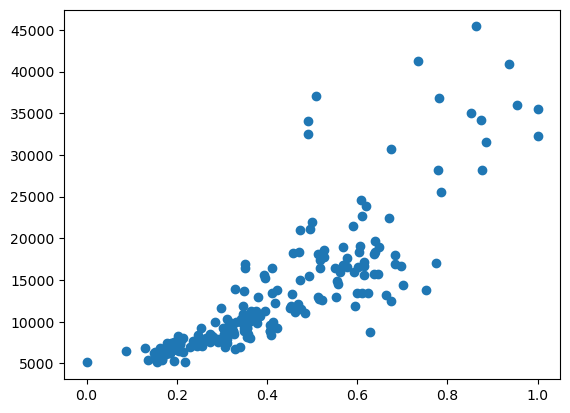

In [141]:
plt.scatter(X[6], y)
plt.show();

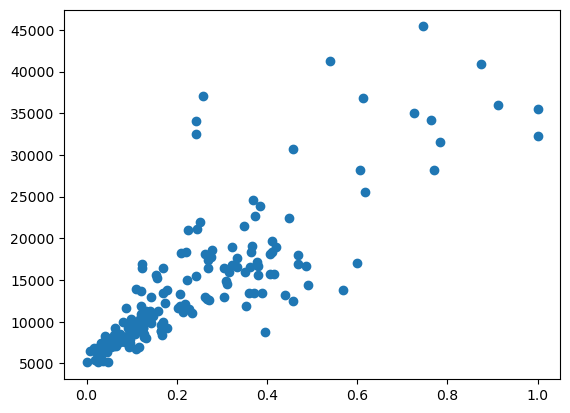

In [143]:
plt.scatter(X[6] ** 2, y)
plt.show();

А для признака номер 13 линеаризовать зависимость получается с помощью функции $\frac 1 {\sqrt{x}}$:

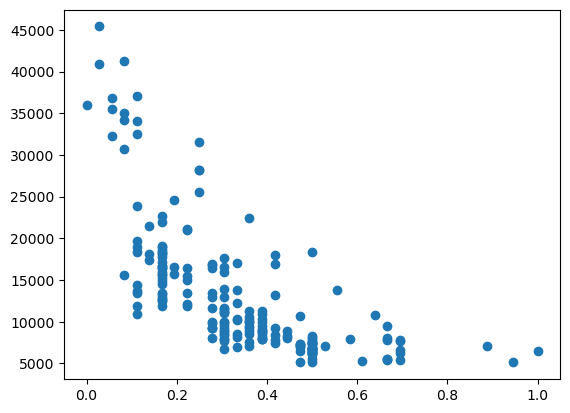

In [147]:
plt.scatter(X[13], y)
plt.show();

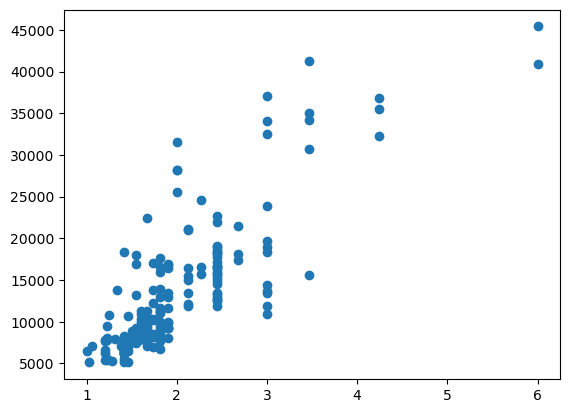

In [149]:
plt.scatter(1 / np.sqrt(X[13]), y)
plt.show();

## 2.  Измерение ошибки в задачах регрессии

Чтобы обучать регрессионные модели, нужно определиться, как именно измеряется качество предсказаний.

Пусть $y$ - значение целевой переменной, $a$ — прогноз модели. Рассмотрим несколько способов оценить отклонение $L(y, a)$ прогноза от истинного ответа.   
$L(y, a)$ называют <u>функцией потерь</u>, задающей <u>штраф</u> за разницу между предсказанием и истинным значением целевого признака. Свойства функции потерь:
* $L(y_i, a(x_i)) \geqslant 0$;
* $L(y_i, y_i) = 0$.



<u>Функционал качества</u> (<u>функционал ошибки</u>) в задачах обучения с учителем обычно задается в виде суммы по объектам выборки:
$$Q(a) = \frac 1 \ell \sum_{i=1}^\ell L(y_i, a(x_i))$$

__Пример:__ если мы не различаем маленькие ошибки (между 0.01 и 0.1 нет особой разницы), но зато не хотим получать большие ошибки, можно использовать следующую функцию потерь:

$$L(y_i, a(x_i)) = [| y_i - a(x_i) | < \varepsilon],$$ $\varepsilon$ — допустимая разница между предсказанием и фактом.

### MSE

$L(y_i, a(x_i)) = (a(x_i) - y_i)^2$

__Среднеквадратичная ошибка (Mean Squared Error, MSE)__: 

$$MSE (a, X) = \frac{1}{l}\sum^l_{i=1}(a(x_i) - y_i)^2$$

MSE не обладает свойством устойчивости к шумовым объектам, потому что задает очень большие штрафы за большие отклонения от фактического значения.

**Пример**. Выберем признак (имеющий индекс 7 в матрице X) и целевой признак (имеющий индекс 15 в матрице X). Добавим к полученной выборке два объекта-выброса и посмотрим, как изменится оптимизированная на MSE прямая.


In [151]:
from sklearn.linear_model import LinearRegression #про линейную регрессию будет ниже 

In [153]:
#Будем предсказывать признак 15 по признаку 7
X_subset = X[[7, 15]].values
X_subset

array([[0.26037736, 0.        ],
       [0.26037736, 0.        ],
       [0.34339623, 0.        ],
       [0.18113208, 1.        ],
       [0.28301887, 1.        ],
       [0.28301887, 1.        ],
       [0.28301887, 1.        ],
       [0.28301887, 1.        ],
       [0.26415094, 1.        ],
       [0.26415094, 1.        ],
       [0.17735849, 0.        ],
       [0.17735849, 0.        ],
       [0.38867925, 0.        ],
       [0.38867925, 0.        ],
       [0.38867925, 0.        ],
       [0.55849057, 0.        ],
       [0.55849057, 0.        ],
       [0.55849057, 0.        ],
       [0.        , 0.        ],
       [0.10943396, 0.        ],
       [0.10943396, 0.        ],
       [0.10943396, 0.        ],
       [0.10943396, 0.        ],
       [0.13962264, 0.        ],
       [0.10943396, 0.        ],
       [0.10943396, 0.        ],
       [0.10943396, 0.        ],
       [0.13962264, 0.        ],
       [0.23018868, 0.        ],
       [0.35849057, 0.        ],
       [0.

In [155]:
#добавление двух шумовых точек (двух выбросов)
X_subset_modified = np.vstack((X_subset, [[1, 90], [2, 50]])) 
X_subset_modified

# np.vstack (от vertical stack) — это функция библиотеки NumPy, 
#которая вертикально соединяет два массива. Она принимает на вход несколько массивов и складывает их друг над другом.

array([[2.60377358e-01, 0.00000000e+00],
       [2.60377358e-01, 0.00000000e+00],
       [3.43396226e-01, 0.00000000e+00],
       [1.81132075e-01, 1.00000000e+00],
       [2.83018868e-01, 1.00000000e+00],
       [2.83018868e-01, 1.00000000e+00],
       [2.83018868e-01, 1.00000000e+00],
       [2.83018868e-01, 1.00000000e+00],
       [2.64150943e-01, 1.00000000e+00],
       [2.64150943e-01, 1.00000000e+00],
       [1.77358491e-01, 0.00000000e+00],
       [1.77358491e-01, 0.00000000e+00],
       [3.88679245e-01, 0.00000000e+00],
       [3.88679245e-01, 0.00000000e+00],
       [3.88679245e-01, 0.00000000e+00],
       [5.58490566e-01, 0.00000000e+00],
       [5.58490566e-01, 0.00000000e+00],
       [5.58490566e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00],
       [1.09433962e-01, 0.00000000e+00],
       [1.09433962e-01, 0.00000000e+00],
       [1.09433962e-01, 0.00000000e+00],
       [1.09433962e-01, 0.00000000e+00],
       [1.39622642e-01, 0.00000000e+00],
       [1.094339

In [69]:
#функция для отрисовки данных
def scatter_points_and_plot_line_MSE(
    X_subset: np.array, ax: matplotlib.axes._axes.Axes
    #X_subset: np.array: Входной параметр, который представляет собой массив, содержащий значения двух переменных 
    #— признака (независимой переменной) и целевой переменной (зависимой переменной).
#ax: matplotlib.axes._axes.Axes: Объект осей matplotlib, на которых будут построены графики.
) -> None:
    # визуализируем точки (признак - таргет)
    ax.scatter(X_subset[:, 0], X_subset[:, 1])
#    X_subset[:, 0]: Это первая колонка массива X_subset, которая содержит значения независимой переменной (признак 7).
# X_subset[:, 1]: Это вторая колонка массива X_subset, которая содержит значения зависимой переменной (признак 15).
#по оси X откладываются значения признака, а по оси Y — значения целевой переменной.
    # обучим линейную модель (обычная линейная регрессия)
    lr = LinearRegression()
    lr.fit(X_subset[:, 0][:, np.newaxis], X_subset[:, 1])
    # X_subset[:, 0][:, np.newaxis]: Преобразуем одномерный массив 
    # (первая колонка) в двумерный массив (вектор-столбец).
#lr.fit(): Метод обучает модель на этих данных, определяя коэффициенты линейной регрессии.
    
    # визуализируем прямую
    grid = np.linspace(0, 2, 100) #точки по оси x 100 in равномерно распред между 0 и 2
    line = lr.predict(grid[:, np.newaxis]) #предсказанные значения, Метод возвращает предсказанные значения на основе модели.
    ax.plot(grid, line) #  Рисуем линию, используя предсказанные значения. Она показывает тренд линейной регрессии, основанный на обученных данных 
    ax.set_ylim(-20, 100) # диапазон значений такой чтобы увидеть доб точки
    ax.set_xlabel("x")
    ax.set_ylabel("y")

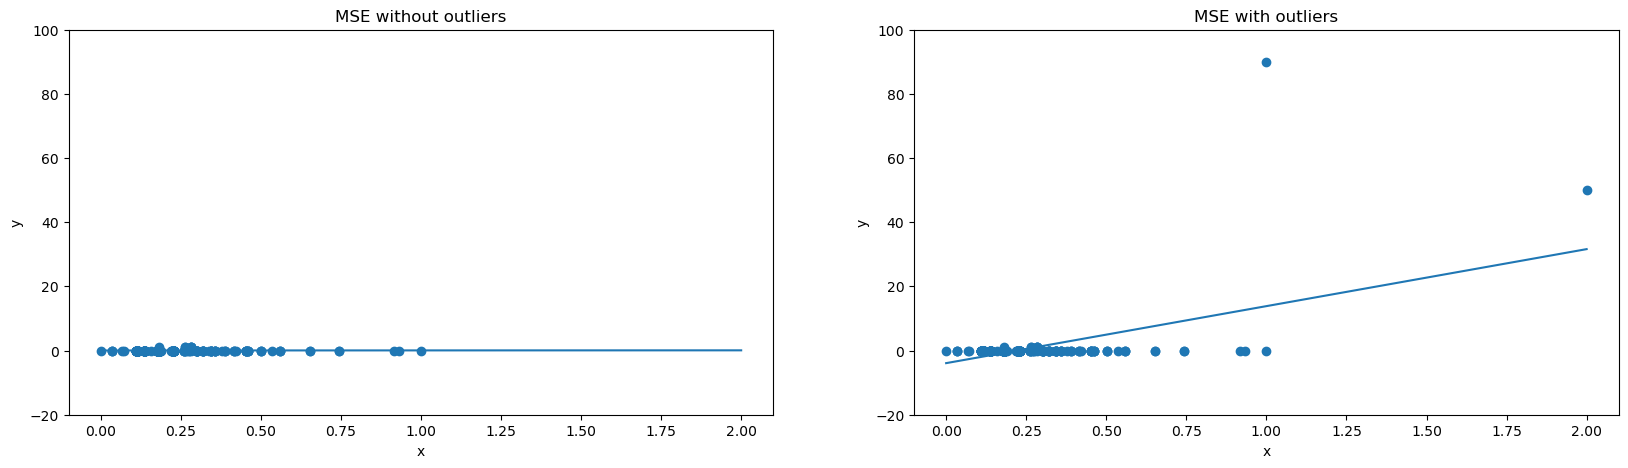

In [157]:
_, ax = plt.subplots(1, 2, figsize=(20, 5))
ax[0].set_title("MSE without outliers") #без выбросов
scatter_points_and_plot_line_MSE(X_subset, ax[0])
ax[1].set_title("MSE with outliers")   #с выбросами
scatter_points_and_plot_line_MSE(X_subset_modified, ax[1])
plt.show();

**Задание.** Реализуйте функцию для подсчета MSE с использованием numpy.

In [159]:
def MSE(y: np.array, y_pred: np.array) -> np.float64:
 
    return ((y-y_pred)**2).mean()


a = np.array([11, 20, 19, 17, 10])
pred = np.array([12, 18, 19.5, 18, 9])
mse = MSE(y=a, y_pred=pred)
print(f"Mean Square Error is: {mse}")
assert mse == 1.45

Mean Square Error is: 1.45


Альтернативный вариант (sklearn):

In [161]:
from sklearn.metrics import mean_squared_error

In [163]:
print(f"Mean Square Error is: {mean_squared_error(a, pred)}")

Mean Square Error is: 1.45


In [ ]:
mean_squared_error?

*__Примечание__. Если использовать MSE как функционал качества (для обучения), то в формуле для MSE на $l$ можно не делить.
Если использовать MSE как метрику качества (для оценки качества модели), то в формуле для MSE нужно деление на $l$, и лучше
извлекать корень из MSE, т.е. иcпользовать метрику RMSE.*

### RMSE

Среднеквадратичная ошибка подходит для сравнения двух моделей или для контроля качества во время обучения. Из-за того, что разница возводится в квадрат, сложно дать этому числу интерпретацию. 

Для лучшей интерпретации используется __Root Mean Square Error (RMSE)__: её значение имеет те же масштабы, что и целевая переменная.

$$RMSE (a, X) = \sqrt{MSE (a, X)} = \sqrt{ \sum^l_{i=1}(a(x_i) - y_i)^2}$$

**Задание.** Реализуйте функцию для подсчета RMSE с использованием numpy.

In [165]:
def RMSE(y: np.array, y_pred: np.array) -> np.float64:
    # <YOUR CODE HERE>
    return np.sqrt(MSE(y,y_pred))

rmse = RMSE(y=a, y_pred=pred)
print(f"Root Mean Square Error is: {rmse}")
assert rmse == 1.2041594578792296

Root Mean Square Error is: 1.2041594578792296


### $R^2$

__Коэффициент детерминации $R^2$__ показывает долю дисперсии в целевой переменной, которая объяснена зависимыми переменными.   ($R^2$ можно интерпретировать как некоторого рода нормированное MSE).

$$R^2(a, X, Y) = 1 - \frac {\sum^L_{i=1}(a(x_i) - y_i)^2}{\sum^L_{i=1}(y_i - \bar{y})^2}$$ или 
$$R^2(a, X, Y) = 1 - \frac {\frac{1}{l}\sum^l_{i=1}(a(x_i) - y_i)^2}{\frac{1}{l}\sum^l_{i=1}(y_i - \bar{y})^2}$$
- Если $R^2 < 0$, значит наша модель даёт предсказание хуже константы в виде среднего значения целевой переменной, то есть абсолютно бесполезна с точки зрения MSE.
- Если $R^2 = 0$, значит мы предсказываем не лучше и не хуже константы в виде среднего значения целевой переменной.
- Если $0 < R^2 < 1$, значит модель работает лучше константного предсказания с точки зрения MSE.
- Если $R^2 = 1$, значит ошибка MSE равна нулю. 

**Задание.** Реализуйте функцию для подсчета $R^2$ с использованием numpy.

In [167]:
def R_squared(y: np.array, y_pred: np.array) -> np.float64:
    # <YOUR CODE HERE>
    std = ((y - np.mean(y))**2).mean()
    return 1 - MSE(y,y_pred)/std


r_squared = R_squared(y=a, y_pred=pred)
print(f"R2 score is: {r_squared}")

R2 score is: 0.914906103286385


Альтернативный вариант (sklearn):

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
print(f"r2_score is: {r2_score(a, pred)}")

### MAE

$L(y_i, a(x_i)) = |a(x_i) - y_i|$

__Средняя абсолютная ошибка (Mean Absolute Error, MAE)__:

$$MAE(a, X) = \frac {1}{l} \sum^l_{i=1}|a(x_i) - y_i|$$

Из-за того, что в MSE мы учитываем квадрат отклонения, шумовые объекты могут сильно изменить наклон прямой. Поэтому в качестве альтернативы MSE можно использовать MAE.

**Задание.** Реализуйте функцию для подсчета MAE с использованием numpy.

In [169]:
def MAE(y: np.array, y_pred: np.array) -> np.float64:
   
    return np.abs(y-y_pred).mean()


mae = MAE(y=a, y_pred=pred)
print(f"Mean Absolute Error is: {mae}")
assert mae == 1.1

Mean Absolute Error is: 1.1


Альтернативный вариант (sklearn):

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
print(f"MAE is: {mean_absolute_error(a, pred)}")

---